In [40]:
# Импорты и загрузка данных 
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Доступ к проектным модулям
if '../src' not in sys.path:
    sys.path.append('../src')
from database import load_worst_corrosion_by_component as load_data

# Загрузка полного датасета (запускать редко — долго)
DF_full = load_data()

In [41]:
# Целевая переменная
TARGET = 'corr_rate_worst_mm_per_year'

assert TARGET in DF_full.columns, f'В данных отсутствует {TARGET}'

print(f"Полный датасет: {len(DF_full):,} строк, {len(DF_full.columns)} колонок")
print('Колонки:', sorted(DF_full.columns.tolist()))

Полный датасет: 36,093 строк, 62 колонок
Колонки: ['ammonia_content', 'ammonium_chloride_content', 'avg_corr_rate_mm_per_year', 'chloride_aggressiveness', 'chlorine_content', 'co2_content', 'component', 'component_id', 'component_type', 'component_type_code', 'contour', 'corr_rate_worst_mm_per_year', 'corrosion_aggressiveness_index', 'corrosion_inhibitor_content', 'corrosion_protection_index', 'cross_section_area_mm2', 'curr_measurement_date', 'curr_thickness_avg_mm', 'curr_thickness_worst_mm', 'delta_years', 'effective_start_date', 'equipment', 'equipment_age_years', 'equipment_id', 'h2s_aggressiveness_index', 'h2s_content', 'h2s_water_ratio', 'hydrochloric_acid_content', 'initial_thickness', 'inner_diameter', 'installation', 'installation_id', 'material_code', 'material_code_id', 'material_grade', 'material_resistance_score', 'material_type', 'max_corr_rate_mm_per_year', 'min_corr_rate_mm_per_year', 'nominal_eff', 'nominal_thickness_mmc', 'num_points_in_section', 'num_sections', 'out

In [42]:
def analyze_correlations(columns, title, df=None):
    """Строит матрицу корреляций Спирмена и heatmap по списку параметров.
    columns — список имён параметров, title — название графика."""
    if df is None:
        df = globals().get('DF_loaded', globals().get('DF_full'))
    cols_use = [c for c in columns if c in df.columns]
    df_work = df[cols_use].copy().select_dtypes(include=[np.number]).dropna(how='all', axis=1)
    if df_work.empty or len(df_work.columns) < 2:
        print("Недостаточно числовых столбцов для корреляции.")
        return
    print(f"Параметры: {list(df_work.columns)}\nСтрок: {len(df_work):,}")
    corr_spearman = df_work.corr(method='spearman')
    print("\nМатрица корреляций Спирмена:\n", corr_spearman.round(3))
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_scatter_vs_target(columns, title, target=None, df=None):
    """Точечные графики: двумерная зависимость переменных от целевой (Y).
    columns — список признаков по оси X, title — название графика, target — целевая переменная (по умолчанию TARGET)."""
    if df is None:
        df = globals().get('DF_loaded', globals().get('DF_full'))
    if target is None:
        target = TARGET
    if target not in df.columns:
        print(f"Целевая переменная '{target}' отсутствует в данных.")
        return
    cols_use = [c for c in columns if c in df.columns and c != target]
    if not cols_use:
        print("Нет подходящих столбцов для построения графика.")
        return
    n = len(cols_use)
    if n == 1:
        fig, ax = plt.subplots(figsize=(8, 5))
        axes = [ax]
    else:
        ncols = min(2, n)
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows))
        axes = np.atleast_1d(axes).flatten()
        for a in axes[n:]:
            a.set_visible(False)
    y_label = "Скорость коррозии, мм/год" if "corr_rate" in target else target
    for idx, x_col in enumerate(cols_use):
        ax = axes[idx]
        data = df[[x_col, target]].dropna()
        if data.empty:
            ax.text(0.5, 0.5, "Нет данных", ha="center", va="center", transform=ax.transAxes)
        else:
            ax.scatter(data[x_col], data[target], alpha=0.4, s=15, c="steelblue", edgecolors="none")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_label if n == 1 else target)
        if n > 1:
            ax.set_title(x_col)
    if n > 1:
        fig.suptitle(title, y=1.02)
    else:
        axes[0].set_title(title)
    plt.tight_layout()
    plt.show()
    if n == 1 and not data.empty:
        print(f"Точек: {len(data):,}")
    elif n > 1:
        print(f"Построено подграфиков: {n}")

In [ ]:
# Фильтр по установкам: новая переменная — быстрый перезапуск без повторной загрузки
# 54 - АВТ-6
# 68 - АВТ-2
# 53 - АВТ-1
# 80 - АВТ-5
# corrosion_aggressiveness_index                        0.141
# h2s_content                                           0.101
# 4 - KK-2
# 51- КК
INSTALLATION_IDS = [4,51]  # Список ID установок для фильтрации 


# Фильтрация по списку установок
DF_loaded = DF_full[DF_full['installation_id'].isin(INSTALLATION_IDS)].copy()
DF_loaded = DF_loaded.sort_values('installation_id').reset_index(drop=True)

print(f"Отфильтровано (installation_id in {INSTALLATION_IDS}): {len(DF_loaded):,} строк")
print(f"Распределение по установкам:")
print(DF_loaded['installation_id'].value_counts().sort_index())

Отфильтровано (installation_id in [4, 51]): 14,480 строк
Распределение по установкам:
installation_id
4     6951
51    7529
Name: count, dtype: int64


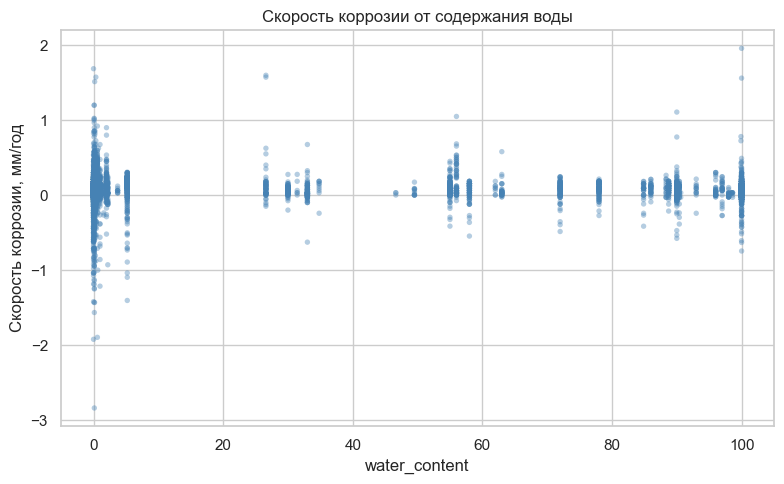

Точек: 8,987


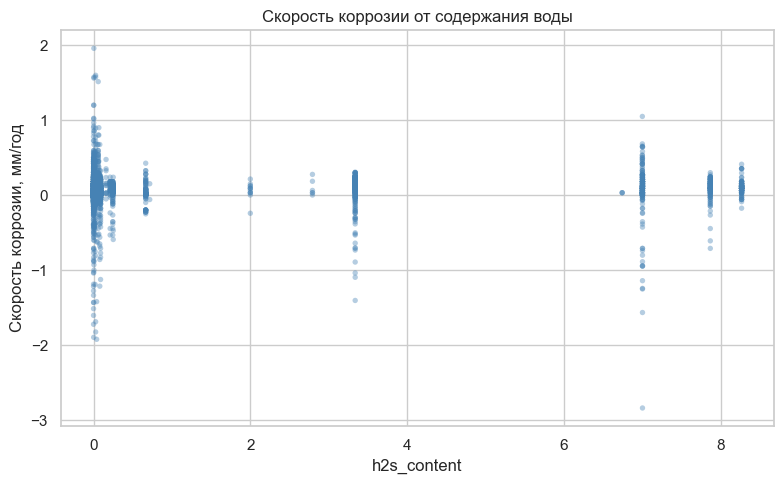

Точек: 5,310


In [85]:
# Точечный график: зависимость переменной от целевой (скорость коррозии)
plot_scatter_vs_target(['water_content'], 'Скорость коррозии от содержания воды')
# Точечный график: зависимость переменной от целевой (скорость коррозии)
plot_scatter_vs_target(['h2s_content'], 'Скорость коррозии от содержания воды')

Параметры: ['corr_rate_worst_mm_per_year', 'equipment_age_years', 'chloride_aggressiveness', 'corrosion_aggressiveness_index', 'corrosion_inhibitor_content', 'material_resistance_score']
Строк: 14,480

Матрица корреляций Спирмена:
                                 corr_rate_worst_mm_per_year  \
corr_rate_worst_mm_per_year                           1.000   
equipment_age_years                                  -0.224   
chloride_aggressiveness                              -0.008   
corrosion_aggressiveness_index                        0.093   
corrosion_inhibitor_content                             NaN   
material_resistance_score                             0.018   

                                equipment_age_years  chloride_aggressiveness  \
corr_rate_worst_mm_per_year                  -0.224                   -0.008   
equipment_age_years                           1.000                   -0.043   
chloride_aggressiveness                      -0.043                    1.000   
corros

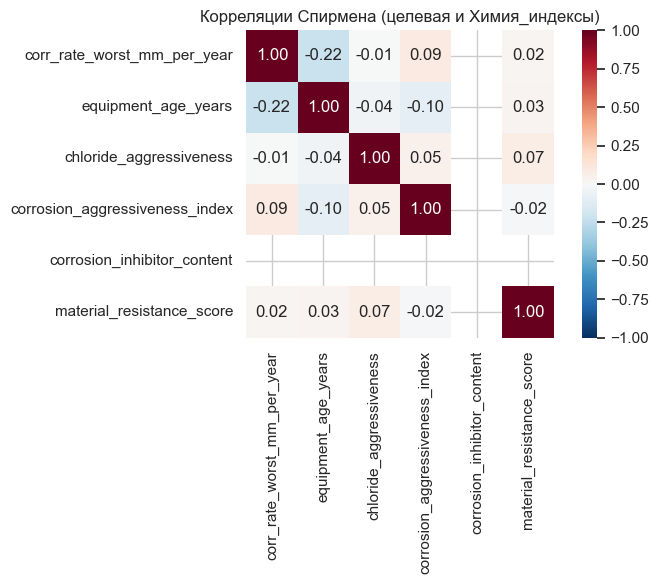

Параметры: ['corr_rate_worst_mm_per_year', 'ammonium_chloride_content', 'chlorine_content', 'co2_content', 'corrosion_inhibitor_content', 'h2s_content', 'oxygen_content', 'sodium_hydroxide_content', 'water_content']
Строк: 14,480

Матрица корреляций Спирмена:
                              corr_rate_worst_mm_per_year  \
corr_rate_worst_mm_per_year                        1.000   
ammonium_chloride_content                          0.017   
chlorine_content                                   0.231   
co2_content                                        0.030   
corrosion_inhibitor_content                          NaN   
h2s_content                                        0.115   
oxygen_content                                    -0.015   
sodium_hydroxide_content                           0.129   
water_content                                      0.070   

                             ammonium_chloride_content  chlorine_content  \
corr_rate_worst_mm_per_year                      0.017        

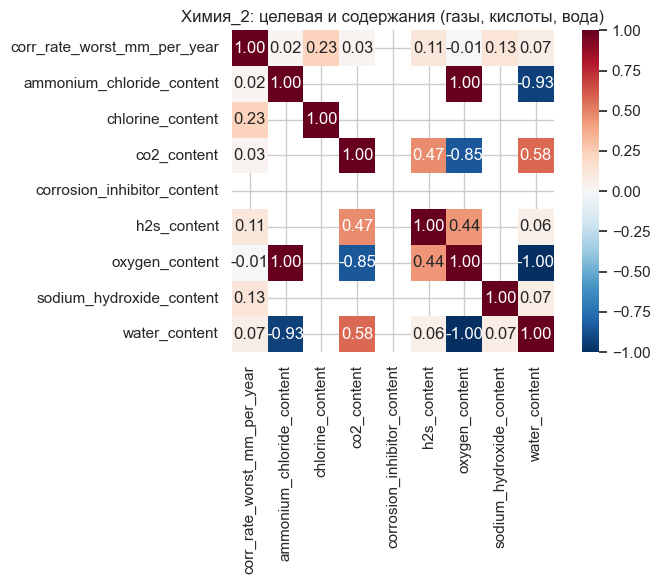

Параметры: ['corr_rate_worst_mm_per_year', 'corrosion_protection_index', 'h2s_aggressiveness_index', 'h2s_water_ratio', 'pitting_corrosion_index', 'stress_corrosion_index', 'underdeposit_corrosion_index']
Строк: 14,480

Матрица корреляций Спирмена:
                               corr_rate_worst_mm_per_year  \
corr_rate_worst_mm_per_year                         1.000   
corrosion_protection_index                          0.032   
h2s_aggressiveness_index                            0.103   
h2s_water_ratio                                     0.113   
pitting_corrosion_index                            -0.006   
stress_corrosion_index                              0.092   
underdeposit_corrosion_index                        0.091   

                              corrosion_protection_index  \
corr_rate_worst_mm_per_year                        0.032   
corrosion_protection_index                         1.000   
h2s_aggressiveness_index                          -0.100   
h2s_water_ratio      

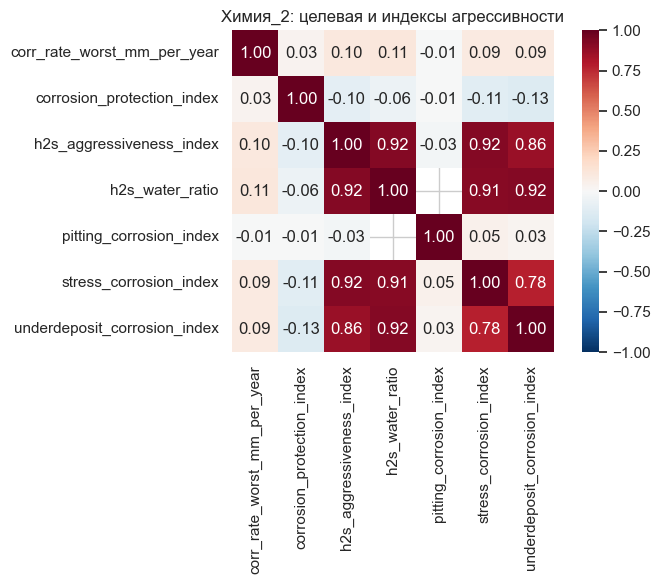

Параметры: ['corr_rate_worst_mm_per_year', 'total_acidity_index', 'total_acids', 'total_chlorine_compounds', 'total_sulfur_compounds']
Строк: 14,480

Матрица корреляций Спирмена:
                              corr_rate_worst_mm_per_year  total_acidity_index  \
corr_rate_worst_mm_per_year                        1.000               -0.017   
total_acidity_index                               -0.017                1.000   
total_acids                                       -0.017                1.000   
total_chlorine_compounds                          -0.008               -0.036   
total_sulfur_compounds                             0.054                0.362   

                             total_acids  total_chlorine_compounds  \
corr_rate_worst_mm_per_year       -0.017                    -0.008   
total_acidity_index                1.000                    -0.036   
total_acids                        1.000                    -0.036   
total_chlorine_compounds          -0.036             

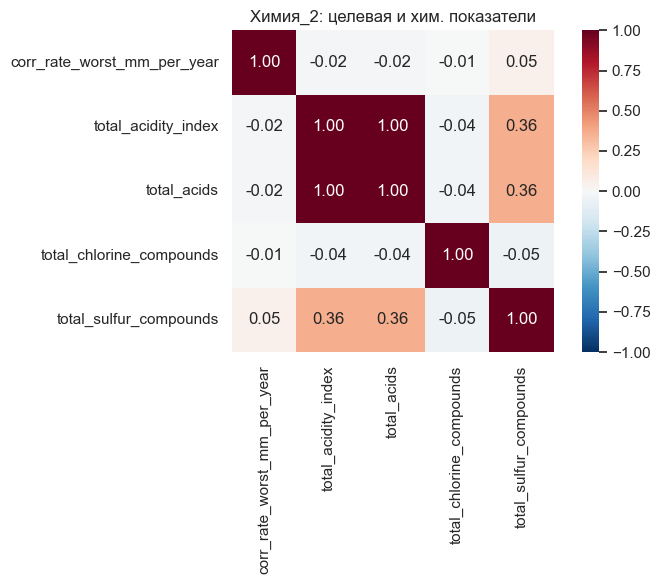

Параметры: ['corr_rate_worst_mm_per_year', 'cross_section_area_mm2', 'inner_diameter', 'nominal_thickness_mmc', 'outer_diameter']
Строк: 14,480

Матрица корреляций Спирмена:
                              corr_rate_worst_mm_per_year  \
corr_rate_worst_mm_per_year                        1.000   
cross_section_area_mm2                             0.137   
inner_diameter                                     0.111   
nominal_thickness_mmc                              0.149   
outer_diameter                                     0.123   

                             cross_section_area_mm2  inner_diameter  \
corr_rate_worst_mm_per_year                   0.137           0.111   
cross_section_area_mm2                        1.000           0.946   
inner_diameter                                0.946           1.000   
nominal_thickness_mmc                         0.861           0.699   
outer_diameter                                0.981           0.989   

                             nominal_

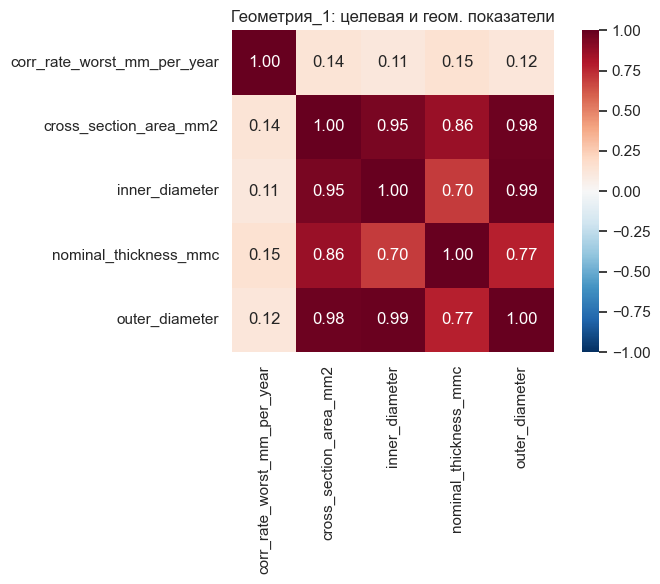

In [84]:
COLS = [
    'corr_rate_worst_mm_per_year',
    'equipment_age_years',
    'chloride_aggressiveness',
    'corrosion_aggressiveness_index',
    'corrosion_inhibitor_content',
    'material_resistance_score',

]
analyze_correlations(COLS, 'Корреляции Спирмена (целевая и Химия_индексы)')

# Блок 1: целевая + содержания (газы, кислоты, вода)
COLS_1 = [
    'corr_rate_worst_mm_per_year',
    'ammonia_content',
    'ammonium_chloride_content',
    'chlorine_content',
    'co2_content',
    'corrosion_inhibitor_content',
    'h2s_content',
    'hydrochloric_acid_content',
    'oxygen_content',
    'sodium_hydroxide_content',
    'water_content',
]
analyze_correlations(COLS_1, 'Химия_2: целевая и содержания (газы, кислоты, вода)')

# Блок 2: целевая + индексы агрессивности
COLS_2 = [
    'corr_rate_worst_mm_per_year',
    'corrosion_protection_index',
    'h2s_aggressiveness_index',
    'h2s_water_ratio',
    'pitting_corrosion_index',
    'stress_corrosion_index',
    'underdeposit_corrosion_index',
]
analyze_correlations(COLS_2, 'Химия_2: целевая и индексы агрессивности')

# Блок 3: целевая + суммарные показатели и кислотность
COLS_3 = [
    'corr_rate_worst_mm_per_year',
    'total_acidity_index',
    'total_acids',
    'total_chlorine_compounds',
    'total_sulfur_compounds',
]
analyze_correlations(COLS_3, 'Химия_2: целевая и хим. показатели')

COLS_4 = [
    'corr_rate_worst_mm_per_year',
    'cross_section_area_mm2',
    'inner_diameter',
    'nominal_thickness_mmc',
    'outer_diameter',
    'material_grade'
    ]

analyze_correlations(COLS_4, 'Геометрия_1: целевая и геом. показатели')
